W ramach pracy należy:
- analizy przeprowadzić osobno dla zmiennej kategoryzowanej i zmiennej numerycznej (obie metody)
- określić częściowe zależności liniowe pomiędzy zmiennymi wyjaśnianymi a wyjaśnianymi. Analizy dokonać poprzez wstępny podział zbioru na mniejsze podzbiory przy pomocy drzew decyzyjnych, a następnie zbadać zależności przy pomocy zespołu (ensemble) modeli liniowych. Należy pamiętać o transformacjach (CART + LS)
- wskazać, które zmienne zachowują się nieliniowo i czy zmiany te są uzasadnione rozkładem tych zmiennych (GAM)
- Wskazać jaka część zakresu zmiennych wpływa na zwyżkę ceny (lub zwiększa prawdpodobieństwo zainteresowania) a jaka obniża te cechy (GAM)
- Przeanalizować i odpowiedzieć na pytanie: Czy wszystkie zmienne wyjaśniające powinny być numeryczne? (co zrobić gdy nie są)

In [5]:
from scipy import stats
import numpy as np
import pandas as pd

In [6]:
data = pd.read_csv("dane/zal_hausing.csv")
data.head()

,pietro,izby,powierzchnia,zadrzewienie,autostrada,przemysł,centrum,jezioro,lasy,tramwaj,policja,szkola,cena,zainter
0,0,4,65.10,13.44,3153.81100,63.63961,7366.52600,1384.37700,538.56290,472.70500,2996.06800,1324.84000,4531.49,False
1,3,2,32.70,21.56,8452.07227,134.35030,2818.24414,1601.85046,1471.20703,96.04687,1860.02686,289.87067,1972.32,True
2,0,3,40.98,1.20,6571.53900,89.44272,2269.05800,1264.80200,798.82730,40.31129,734.20030,261.72500,2037.58,True
3,3,2,49.53,0.48,11763.63574,207.00241,5615.26953,5416.94092,236.48466,2214.45825,2338.56787,182.48288,5471.43,False
4,4,3,81.40,21.72,4384.95500,169.18920,2375.39500,3475.80900,2024.84600,317.56890,1301.76800,65.00000,3482.80,True


# Przedanaliza datasetu

In [2]:
data.describe()

,pietro,izby,powierzchnia,zadrzewienie,autostrada,przemysł,centrum,jezioro,lasy,tramwaj,policja,szkola,cena
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.685000,2.919000,51.285580,10.183840,6271.578879,205.613426,3384.262134,2317.269380,1186.627256,523.115499,1246.816483,368.796227,5071.979760
std,2.225472,0.993693,19.734143,11.252383,2786.915515,171.783014,1803.970943,1138.933408,739.922508,868.910216,960.593873,281.821413,1364.321629
min,0.000000,1.000000,14.200000,0.000000,810.493700,5.000000,217.082900,161.012400,25.000000,5.000000,15.000000,18.027760,1019.740000
25%,1.000000,2.000000,37.300000,1.600000,4262.866000,88.459030,2269.058000,1448.528250,623.758750,131.813850,684.560747,188.679600,4211.425000
50%,2.000000,3.000000,47.660000,7.380000,5709.588000,152.970600,2957.723000,2146.654000,1024.217655,250.923250,977.835600,285.000000,5016.815000
75%,4.000000,4.000000,61.645000,15.170000,7718.775500,287.706125,4404.830265,3042.618160,1650.740250,571.646200,1649.869500,452.312552,5966.722500
max,14.000000,5.000000,164.170000,100.000000,12895.780000,977.714200,11353.160000,5546.090820,2967.090000,6933.866000,7446.409000,2612.953000,9474.400000


In [3]:
data.isna().sum()

pietro          0
izby            0
powierzchnia    0
zadrzewienie    0
autostrada      0
przemysł        0
centrum         0
jezioro         0
lasy            0
tramwaj         0
policja         0
szkola          0
cena            0
zainter         0
dtype: int64

In [9]:
numeric_cols = data.select_dtypes(include=[float, int]).columns
z_scores = np.abs(stats.zscore(data[numeric_cols]))
outliers = (z_scores > 4)

mask = outliers.sum(axis=1) >= 1

data[numeric_cols].where(outliers)[mask]

,pietro,izby,powierzchnia,zadrzewienie,autostrada,przemysł,centrum,jezioro,lasy,tramwaj,policja,szkola,cena
30,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,NaN,NaN,NaN,NaN,NaN,NaN,11353.16000,NaN,NaN,6933.86600,7446.40900,NaN,NaN
77,NaN,NaN,NaN,NaN,NaN,NaN,11002.00098,NaN,NaN,6555.07812,7023.10840,NaN,NaN
123,NaN,NaN,NaN,NaN,NaN,NaN,10759.41406,NaN,NaN,6288.18945,6697.15820,NaN,NaN
171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1520.008,NaN
192,NaN,NaN,NaN,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.833,NaN
204,NaN,NaN,NaN,NaN,NaN,NaN,10912.64648,NaN,NaN,6443.14551,6829.21826,NaN,NaN
206,NaN,NaN,NaN,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.833,NaN
237,NaN,NaN,146.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1541.833,NaN


Wynik przedanalizy: Nie widać jakiś ekstra odstających błędnych wartości które trzeba by było usunąć

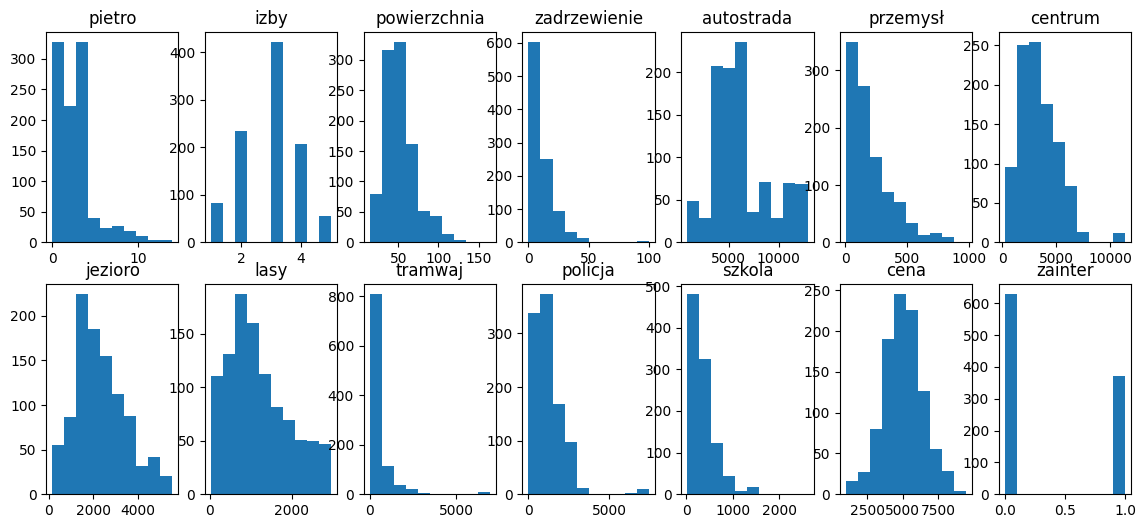

In [10]:
from matplotlib import pyplot as plt
fig,axes = plt.subplots(2, 7, figsize=(14,6))
for column, ax in zip(data.columns, axes.flatten()):
    ax.hist(data[column].astype(float))
    ax.set_title(column)

# Analiza względem ceny